In [1]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score

In [3]:
df = pd.read_csv('creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [36]:
print("Shape:", df.shape)

Shape: (29798, 34)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29799 entries, 0 to 29798
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    29799 non-null  int64  
 1   V1      29799 non-null  float64
 2   V2      29799 non-null  float64
 3   V3      29799 non-null  float64
 4   V4      29799 non-null  float64
 5   V5      29799 non-null  float64
 6   V6      29798 non-null  float64
 7   V7      29798 non-null  float64
 8   V8      29798 non-null  float64
 9   V9      29798 non-null  float64
 10  V10     29798 non-null  float64
 11  V11     29798 non-null  float64
 12  V12     29798 non-null  float64
 13  V13     29798 non-null  float64
 14  V14     29798 non-null  float64
 15  V15     29798 non-null  float64
 16  V16     29798 non-null  float64
 17  V17     29798 non-null  float64
 18  V18     29798 non-null  float64
 19  V19     29798 non-null  float64
 20  V20     29798 non-null  float64
 21  V21     29798 non-null  float64
 22

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,29799.000000,29799.000000,29799.000000,29799.000000,29799.000000,29799.000000,29798.000000,29798.000000,29798.000000,29798.000000,...,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000
mean,21415.425719,-0.209312,0.125470,0.720538,0.213023,-0.203808,0.089008,-0.121495,0.030902,0.351012,...,-0.033872,-0.123746,-0.041956,0.009204,0.132632,0.022783,0.012362,0.004780,79.620566,0.003155
std,12038.537147,1.845781,1.543515,1.613657,1.418989,1.419221,1.321267,1.291495,1.287706,1.257026,...,0.786840,0.640527,0.540717,0.591995,0.435684,0.511026,0.388416,0.273684,222.110430,0.056078
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-9.617915,0.000000,0.000000
25%,10122.000000,-0.951024,-0.446725,0.261163,-0.697463,-0.798822,-0.653976,-0.595929,-0.160211,-0.456677,...,-0.244970,-0.546113,-0.176410,-0.327428,-0.129629,-0.334686,-0.063502,-0.007942,6.540000,0.000000
50%,26182.000000,-0.249361,0.149599,0.844654,0.197721,-0.237290,-0.171222,-0.068568,0.035759,0.244841,...,-0.090713,-0.096810,-0.050365,0.062233,0.172286,-0.057223,0.008246,0.020445,20.000000,0.000000
75%,32195.000000,1.165752,0.788149,1.473903,1.096170,0.312701,0.475508,0.444292,0.294166,1.106549,...,0.083442,0.285024,0.075052,0.398687,0.415022,0.303728,0.089536,0.076514,70.750000,0.000000
max,35634.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,4.860769,7879.420000,1.000000


In [7]:
#missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,1
V7,1
V8,1
V9,1


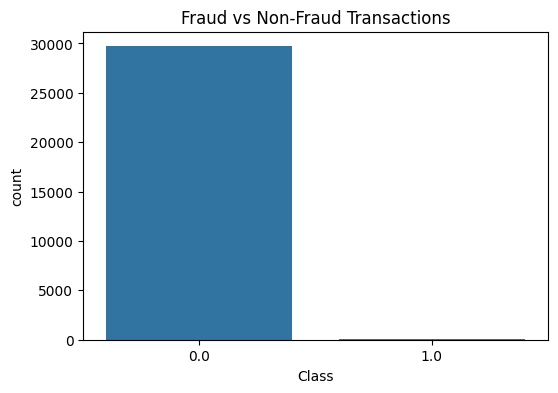



Class
0.0    29704
1.0       94
Name: count, dtype: int64


In [10]:
#fraud distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()
print("\n")
print(df['Class'].value_counts())

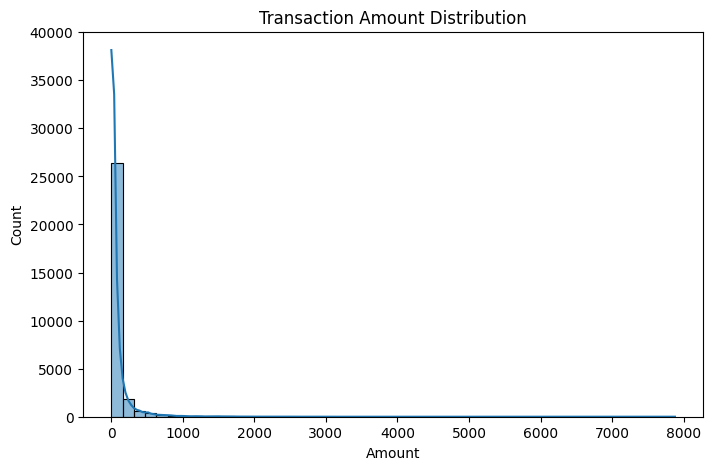

In [11]:
#AMOUNT DISTRIBUTION
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

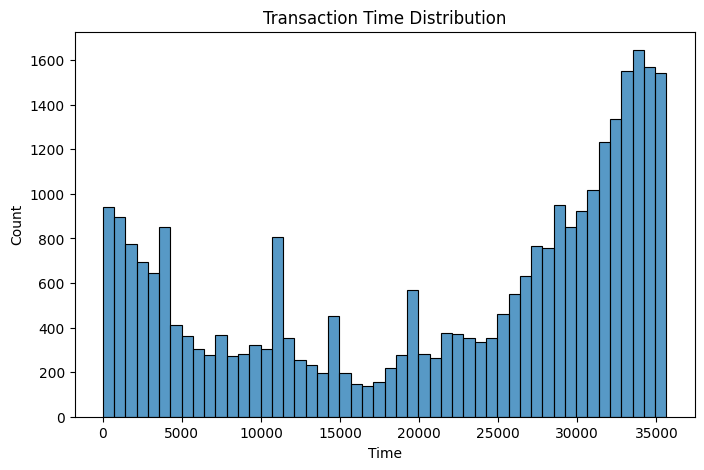

In [12]:
#TIME DISTRIBUTION
plt.figure(figsize=(8,5))
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

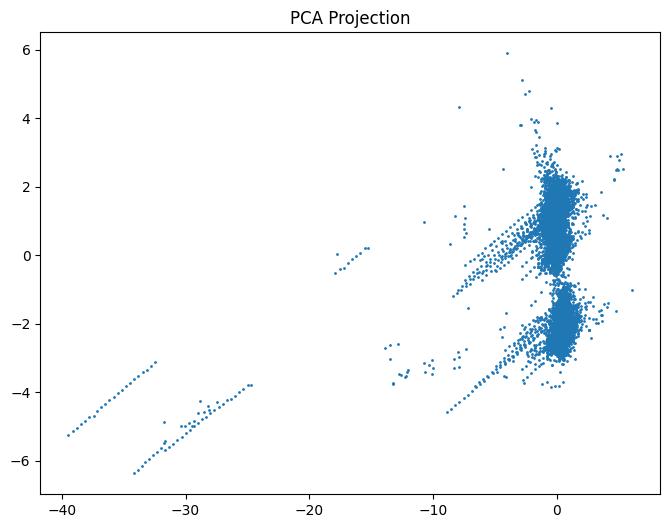

In [19]:
import numpy as np
#DATA PREPROCESSING
# Handle missing values by dropping rows with NaNs
df.dropna(inplace=True)

#SEPERATE FEATURES AND LABELS
X = df.drop('Class', axis=1)
y = df['Class']

#FEATURE SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=1)
plt.title("PCA Projection")
plt.show()

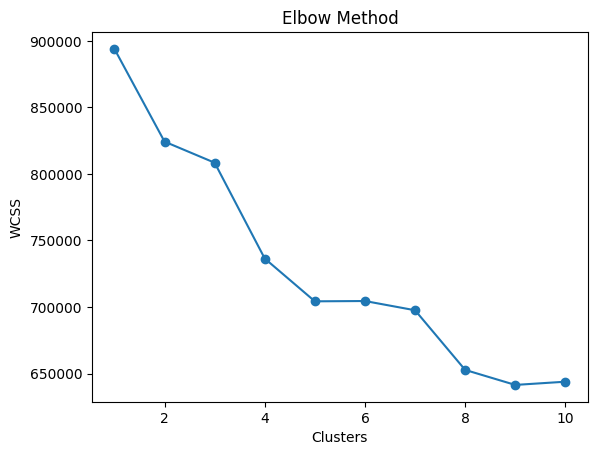

In [20]:
#KMEANS CLUSTERING
#ELBOW METHOD
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [23]:
#TRAIN K-MEANS
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = clusters
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
1,19640
0,10158


In [41]:
cluster_counts = df['KMeans_Cluster'].value_counts()

anomaly_cluster = cluster_counts.idxmin()

df['KMeans_Prediction'] = np.where(
    df['KMeans_Cluster'] == anomaly_cluster,
    1,
    0
)

In [40]:
#ISOLATION FOREST
iso = IsolationForest(
    contamination=0.0017,
    random_state=42
)

df['IF_Prediction'] = iso.fit_predict(X_scaled)
df['IF_Prediction'] = df['IF_Prediction'].map({
    1:0,
    -1:1
})

In [39]:
#COMPARING THE ANOMALIES
print("KMeans Anomalies:")
print(df['KMeans_Prediction'].sum())
print("\n")
print("Isolation Forest Anomalies:")
print(df['IF_Prediction'].sum())

KMeans Anomalies:
10158


Isolation Forest Anomalies:
49


[[19573 10131]
 [   67    27]]


              precision    recall  f1-score   support

         0.0       1.00      0.66      0.79     29704
         1.0       0.00      0.29      0.01        94

    accuracy                           0.66     29798
   macro avg       0.50      0.47      0.40     29798
weighted avg       0.99      0.66      0.79     29798



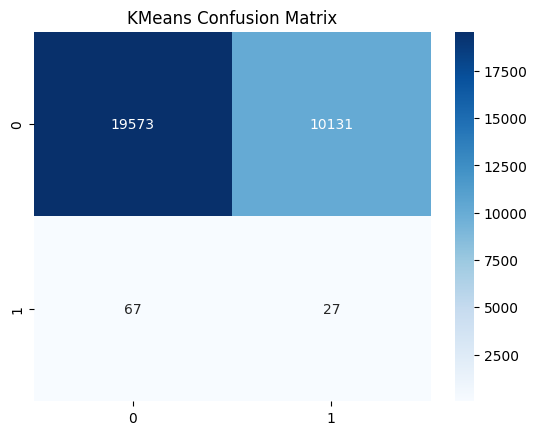



Precision: 0.0026580035440047253
Recall: 0.2872340425531915


In [30]:
#BONUS EVALUATION
#K-MEANS CLUSTERING
cm = confusion_matrix(
    y,
    df['KMeans_Prediction']
)

print(cm)
print("\n")
print(classification_report(
    y,
    df['KMeans_Prediction']
))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("KMeans Confusion Matrix")
plt.show()
print("\n")
print("Precision:",
      precision_score(y,
                      df['KMeans_Prediction']))

print("Recall:",
      recall_score(y,
                   df['KMeans_Prediction']))

[[29687    17]
 [   62    32]]


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     29704
         1.0       0.65      0.34      0.45        94

    accuracy                           1.00     29798
   macro avg       0.83      0.67      0.72     29798
weighted avg       1.00      1.00      1.00     29798



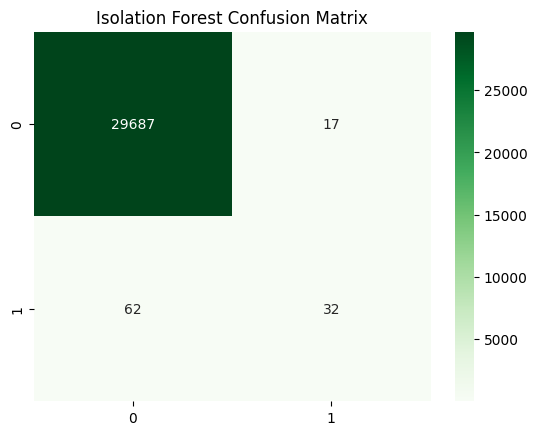

Precision: 0.6530612244897959
Recall: 0.3404255319148936


In [32]:
#ISOLATION FOREST EVALUATION
cm_if = confusion_matrix(
    y,
    df['IF_Prediction']
)

print(cm_if)
print("\n")
print(classification_report(
    y,
    df['IF_Prediction']
))
sns.heatmap(cm_if,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Isolation Forest Confusion Matrix")
plt.show()
print("Precision:",
      precision_score(y,
                      df['IF_Prediction']))

print("Recall:",
      recall_score(y,
                   df['IF_Prediction']))

In [38]:
#FULL CLASSIFICATION
print(classification_report(
    y,
    df['IF_Prediction']
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     29704
         1.0       0.65      0.34      0.45        94

    accuracy                           1.00     29798
   macro avg       0.83      0.67      0.72     29798
weighted avg       1.00      1.00      1.00     29798



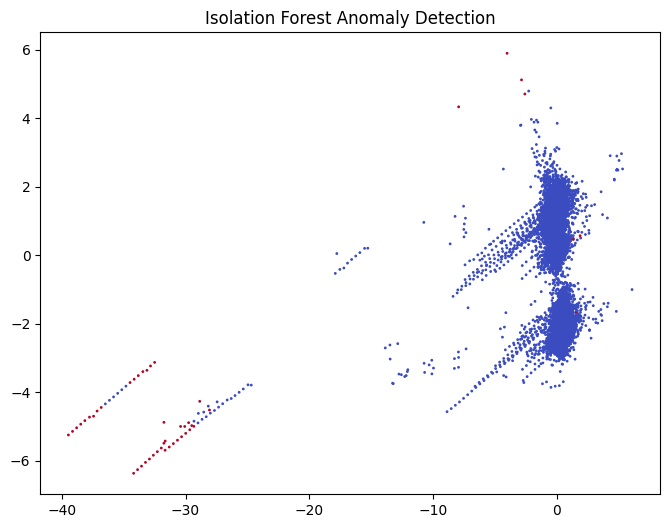

In [34]:
#PCA VISUALIZATION
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['IF_Prediction'],
    cmap='coolwarm',
    s=1
)

plt.title("Isolation Forest Anomaly Detection")
plt.show()

# Problem Understanding

Fraud detection refers to identifying transactions that are intentionally performed to deceive financial institutions for unauthorized financial gain.

Fraud detection is difficult because fraudulent transactions are extremely rare compared to legitimate transactions. This creates severe class imbalance.

Unsupervised learning is suitable because fraud labels may be unavailable, delayed, or incomplete in real-world systems.

# Clustering Approach

K-Means was selected because it groups similar transactions based on feature similarity.

The Elbow Method was used to determine an appropriate number of clusters.

Transactions far from cluster centroids are considered potentially anomalous.

# Anomaly Detection Approach

Isolation Forest was selected because it is specifically designed for anomaly detection.

It isolates anomalies using random feature splits. Anomalous transactions require fewer splits and are therefore identified quickly.

# Comparison of Methods

K-Means groups data into clusters but is not specifically designed for anomaly detection.

Isolation Forest directly targets rare observations and generally performs better for fraud detection.

Therefore Isolation Forest is expected to identify fraudulent transactions more accurately.

#Conclusion

1. The dataset is highly imbalanced with very few fraud cases.

2. K-Means clustering was able to separate transactions into clusters,
but clustering is not specifically designed for anomaly detection.

3. Isolation Forest directly focuses on identifying rare observations
and therefore detected anomalies more effectively.

4. Based on Precision, Recall and Confusion Matrix results,
Isolation Forest performed better than K-Means.

Business Recommendation:
Financial institutions should use Isolation Forest as an early fraud
screening mechanism to flag suspicious transactions for further review.